In [1]:
import os
import datetime
import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

In [13]:
df = pd.read_csv("cold-start-consumption-forecasting-training-data.csv", sep=";")
df

,obs_id,site_id,timestamp,temperature,temperature_-1,temperature_-2,load,load_-1,load_-2,target
0,160021,8,2017-02-09T22:00:00-05:00,5.000000,5.500000,5.033333,129.934636,130.797989,133.819725,133.388048
1,160029,8,2017-02-10T06:00:00-05:00,4.000000,4.500000,5.000000,20568.091737,20691.119548,22141.984374,19903.741553
2,160063,8,2017-02-11T16:00:00-05:00,6.000000,6.000000,6.033333,132.093019,3366.213599,12488.402081,132.093019
3,160082,8,2017-02-12T11:00:00-05:00,8.166667,9.000000,8.500000,11005.161516,13378.519090,13362.978735,15212.281000
4,160112,8,2017-02-13T17:00:00-05:00,6.966667,7.000000,7.000000,131.661342,129.071283,2930.651978,132.093019
...,...,...,...,...,...,...,...,...,...,...
1402443,1289888,71,2016-08-25T20:00:00-04:00,25.133333,25.975000,28.266667,33650.962796,40480.089275,40117.480790,37404.632119
1402444,1289909,71,2016-08-26T17:00:00-04:00,28.666667,29.000000,29.666667,55895.426563,87937.034413,89810.511589,54328.599773
1402445,1289913,71,2016-08-26T21:00:00-04:00,25.450000,25.700000,27.350000,33447.275313,37404.632119,42587.471308,32742.203258
1402446,1289978,71,2016-08-29T14:00:00-04:00,28.166667,28.775000,29.166667,107036.652980,92705.783664,90870.357996,109320.862607


In [22]:
test = df = pd.read_csv("cold-start-consumption-forecasting-test-data.csv", sep=";")
test

,obs_id,site_id,timestamp,temperature,temperature_-1,temperature_-2,load,load_-1,load_-2,target
0,2,78,2017-03-06T15:00:00-05:00,8.000000,8.933333,10.500000,5.245016e+05,5.504866e+05,6.558341e+05,5.133429e+05
1,13,78,2017-07-13T10:00:00-04:00,31.000000,30.000000,29.000000,1.262663e+06,1.245585e+06,1.265211e+06,1.191620e+06
2,16,78,2017-04-05T14:00:00-04:00,16.000000,16.800000,16.500000,6.293816e+05,7.560991e+05,9.208202e+05,7.175366e+05
3,24,78,2016-12-05T01:00:00-05:00,4.500000,6.000000,6.133333,6.502152e+05,5.204650e+05,3.412245e+05,6.782952e+05
4,30,78,2017-09-12T18:00:00-04:00,16.000000,16.000000,17.533333,6.814274e+05,7.720909e+05,8.267658e+05,6.585562e+05
...,...,...,...,...,...,...,...,...,...,...
5371,5326,91,2015-07-28T19:00:00-04:00,23.466667,24.220000,25.420000,1.924487e+03,1.893677e+03,1.936338e+03,0.000000e+00
5372,5353,91,2016-08-13T21:00:00-04:00,17.600000,18.783333,20.000000,1.476546e+03,1.491952e+03,1.520392e+03,0.000000e+00
5373,5354,91,2016-05-24T15:00:00-04:00,19.833333,21.333333,21.533333,1.540538e+03,1.750288e+03,2.842885e+03,0.000000e+00
5374,5360,91,2015-06-20T01:00:00-04:00,19.450000,19.516667,19.866667,1.944633e+03,1.947003e+03,1.976629e+03,0.000000e+00


In [14]:
#df["datetime"] = pd.to_datetime(df["timestamp"], utc=True)
date_time = pd.to_datetime(df["timestamp"], utc=True)

In [15]:
df.head()

,obs_id,site_id,timestamp,temperature,temperature_-1,temperature_-2,load,load_-1,load_-2,target
0,160021,8,2017-02-09T22:00:00-05:00,5.000000,5.5,5.033333,129.934636,130.797989,133.819725,133.388048
1,160029,8,2017-02-10T06:00:00-05:00,4.000000,4.5,5.000000,20568.091737,20691.119548,22141.984374,19903.741553
2,160063,8,2017-02-11T16:00:00-05:00,6.000000,6.0,6.033333,132.093019,3366.213599,12488.402081,132.093019
3,160082,8,2017-02-12T11:00:00-05:00,8.166667,9.0,8.500000,11005.161516,13378.519090,13362.978735,15212.281000
4,160112,8,2017-02-13T17:00:00-05:00,6.966667,7.0,7.000000,131.661342,129.071283,2930.651978,132.093019


(array([15340., 15706., 16071., 16436., 16801., 17167., 17532.]),
 [Text(15340.0, 0, '2012'),
  Text(15706.0, 0, '2013'),
  Text(16071.0, 0, '2014'),
  Text(16436.0, 0, '2015'),
  Text(16801.0, 0, '2016'),
  Text(17167.0, 0, '2017'),
  Text(17532.0, 0, '2018')])

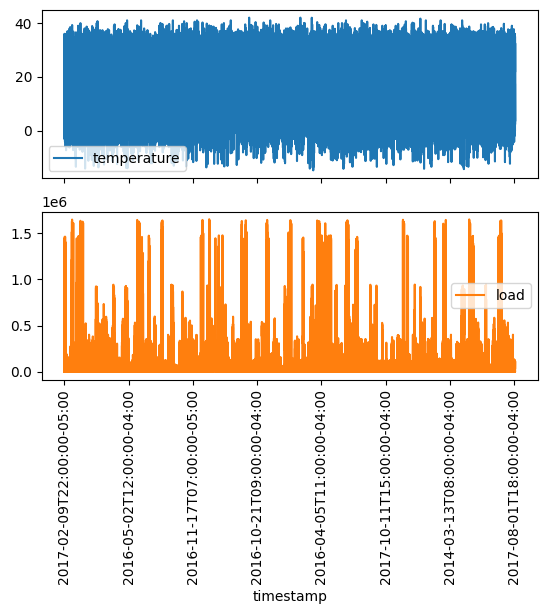

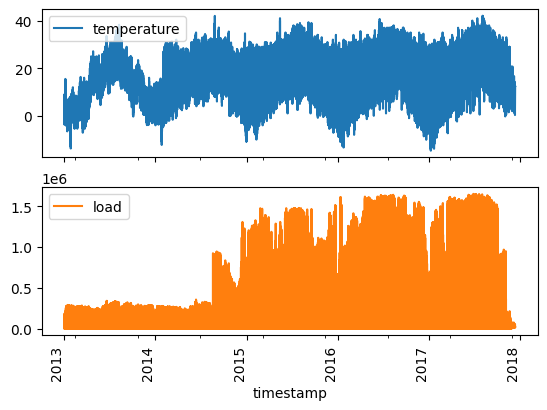

In [21]:
plot_cols = ['temperature', 'load']
plot_features = df[plot_cols]
plot_features.index = df['timestamp']
_ = plot_features.plot(subplots=True)
plt.xticks(rotation=90) 

plot_features = df[plot_cols]
plot_features.index = date_time
_ = plot_features.plot(subplots=True)
plt.xticks(rotation=90) 

In [25]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=df[:10000], val_df=df[10000:11000], test_df=test,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

In [26]:
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1,
    label_columns=['T (degC)'])
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['T (degC)']

In [30]:
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

In [28]:
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [31]:
for example_inputs, example_labels in single_step_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

ValueError: could not convert string to float: '2017-03-06T15:00:00-05:00'

In [32]:
linear = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1)
])

In [34]:
print('Input shape:', single_step_window.example[0].shape)
print('Output shape:', linear(single_step_window.example[0]).shape)

ValueError: could not convert string to float: '2017-03-06T15:00:00-05:00'

In [35]:
MAX_EPOCHS = 20

def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

In [36]:
history = compile_and_fit(linear, single_step_window)

val_performance['Linear'] = linear.evaluate(single_step_window.val)
performance['Linear'] = linear.evaluate(single_step_window.test, verbose=0)

ValueError: could not convert string to float: '2017-03-06T15:00:00-05:00'